In [1]:
import matplotlib.pylab as plt
import cv2

import os
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from models.DRAEM import ReconstructiveSubNetwork, DiscriminativeSubNetwork

from data.field_dataloader import CustomTestDataset
from skimage.filters import threshold_otsu
from sklearn.metrics import roc_auc_score, average_precision_score

In [2]:
test_root_dir = "/home/maria/Documents/dataset_splited/agco_dataset/test/"

batch_size = 1
img_dim = 256
resize_image = (img_dim, img_dim*2)

test_dataset = CustomTestDataset(test_root_dir, resize_shape=resize_image)

test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=6)

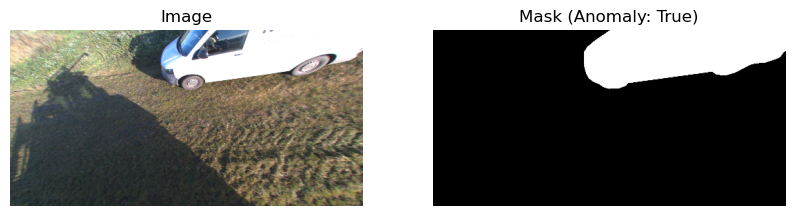

In [3]:
def visualize_patch(sample):
    image = sample['image']
    mask = sample['mask']
    has_anomaly = sample['has_anomaly']
    
    image = np.transpose(image, (1, 2, 0))
    mask = np.transpose(mask, (1, 2, 0))

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f'Mask (Anomaly: {bool(has_anomaly[0])})')
    plt.axis('off')

    plt.show()

sample_idx = -1
sample = test_dataset[sample_idx]

visualize_patch(sample)

#### Model - Scratch

In [4]:
model = ReconstructiveSubNetwork(in_channels=3, out_channels=3)
#model.load_state_dict(torch.load(os.path.join(checkpoint_path,run_name+".pckl"), map_location='cuda:0'))
#model.load_state_dict(torch.load('/home/maria/Documents/projects/anomaly_detection_vehicles/checkpoints_scratch/TEST_DRAEM_10epoch_200.pckl', map_location='cpu'))
model.load_state_dict(torch.load('/home/maria/Documents/projects/anomaly_detection_vehicles/checkpoints_carpet/TEST_DRAEM_CARPET_10epoch_200.pckl', map_location='cpu'))

model.cpu()
model.eval()

model_seg = DiscriminativeSubNetwork(in_channels=6, out_channels=2)
#model_seg.load_state_dict(torch.load(os.path.join(checkpoint_path, run_name+"_seg.pckl"), map_location='cuda:0'))
#model_seg.load_state_dict(torch.load('/home/maria/Documents/projects/anomaly_detection_vehicles/checkpoints_scratch/TEST_DRAEM_10epoch_200_seg.pckl', map_location='cpu'))
model_seg.load_state_dict(torch.load('/home/maria/Documents/projects/anomaly_detection_vehicles/checkpoints_carpet/TEST_DRAEM_CARPET_10epoch_200_seg.pckl', map_location='cpu'))

model_seg.cpu()
model_seg.eval()

DiscriminativeSubNetwork(
  (encoder_segment): EncoderDiscriminative(
    (block1): Sequential(
      (0): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (mp1): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [5]:
total_pixel_scores = np.zeros((img_dim * img_dim*2 * len(test_dataset)))
total_gt_pixel_scores = np.zeros((img_dim * img_dim*2 * len(test_dataset)))
mask_cnt = 0

anomaly_score_gt = []
anomaly_score_prediction = []

display_images = torch.zeros((16 ,3 ,img_dim ,img_dim*2)).cuda()
display_gt_images = torch.zeros((16 ,3 ,img_dim ,img_dim*2)).cuda()
display_out_masks = torch.zeros((16 ,1 ,img_dim ,img_dim*2)).cuda()
display_in_masks = torch.zeros((16 ,1 ,img_dim ,img_dim*2)).cuda()
cnt_display = 0
display_indices = np.random.randint(len(test_loader), size=(16,))

In [6]:
import warnings
warnings.filterwarnings("ignore")
out_dir = "/media/maria/mairj/outputs/pretrained_carpet/perlin"

In [7]:
anomaly_score_gt = []
anomaly_score_prediction = []

for i_batch, sample_batched in enumerate(test_loader):

    if i_batch >= 756:

    #if i_batch >=1:
    #    break

        print(f"Batch: {i_batch}")
        gray_batch = sample_batched["image"].cpu()

        is_normal = sample_batched["has_anomaly"].detach().numpy()[0 ,0]
        anomaly_score_gt.append(is_normal)
        true_mask = sample_batched["mask"]
        true_mask_cv = true_mask.detach().numpy()[0, :, :, :].transpose((1, 2, 0))

        gray_rec = model(gray_batch)
        joined_in = torch.cat((gray_rec.detach(), gray_batch), dim=1)

        out_mask = model_seg(joined_in)
        out_mask_sm = torch.softmax(out_mask, dim=1)


        if i_batch in display_indices:
            t_mask = out_mask_sm[:, 1:, :, :]
            display_images[cnt_display] = gray_rec[0]
            display_gt_images[cnt_display] = gray_batch[0]
            display_out_masks[cnt_display] = t_mask[0]
            display_in_masks[cnt_display] = true_mask[0]
            cnt_display += 1


        out_mask_cv = out_mask_sm[0 ,1 ,: ,:].detach().cpu().numpy()

        out_mask_averaged = torch.nn.functional.avg_pool2d(out_mask_sm[: ,1: ,: ,:], 21, stride=1,
                                                            padding=21 // 2).cpu().detach().numpy()
        image_score = np.max(out_mask_averaged)

        anomaly_score_prediction.append(image_score)

        orig_image = gray_batch[0].cpu().numpy().transpose(1, 2, 0)  # Shape: (224, 448, 3)
        plt.imsave(f"{out_dir}/{i_batch}_original.png", orig_image)

        rec_image = gray_rec[0].detach().cpu().numpy().transpose(1, 2, 0)  # Shape: (224, 448, 3)
        rec_image_clipped = np.clip(rec_image, 0, 1)
        plt.imsave(f"{out_dir}/{i_batch}_reconstructed.png", rec_image_clipped)

        true_mask_np = true_mask[0].squeeze().cpu().numpy()
        cv2.imwrite(f"{out_dir}/{i_batch}_true_mask.png", true_mask_np*255.)

        predicted_mask_normalized = (out_mask_cv - out_mask_cv.min()) / (out_mask_cv.max() - out_mask_cv.min())
        #plt.imsave(f"{out_dir}/{i_batch}_anomaly_map_norm.png", predicted_mask_normalized)

        plt.imsave(f"{out_dir}/{i_batch}_anomaly_map.png", out_mask_cv)


        binary_mask = (predicted_mask_normalized > 0.5).astype(np.uint8)
        cv2.imwrite(f"{out_dir}/{i_batch}_predicted_mask.png", binary_mask*255.)

        '''
        ### Plot
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        orig_image = gray_batch[0].cpu().numpy().transpose(1, 2, 0)  # Shape: (224, 448, 3)
        axes[0].imshow(orig_image)
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        plt.imsave(f"{out_dir}/{i_batch}_original.png", orig_image)
        #plt.savefig(os.path.join(output_dir, f"batch_{i_batch:03d}_original.png"))
        

        rec_image = gray_rec[0].detach().cpu().numpy().transpose(1, 2, 0)  # Shape: (224, 448, 3)
        rec_image_clipped = np.clip(rec_image, 0, 1)
        axes[1].imshow(rec_image_clipped)
        axes[1].set_title("Reconstructed Image")
        axes[1].axis('off')
        plt.imsave(f"{out_dir}/{i_batch}_reconstructed.png", rec_image_clipped)
        #plt.savefig(os.path.join(output_dir, f"batch_{i_batch:03d}_reconstructed.png"))
        

        true_mask_np = true_mask[0].squeeze().cpu().numpy()
        axes[2].imshow(true_mask_cv, cmap='gray')
        axes[2].set_title("True Mask")
        axes[2].axis('off')
        cv2.imwrite(f"{out_dir}/{i_batch}_true_mask.png", true_mask_np*255.)
        #plt.savefig(os.path.join(output_dir, f"batch_{i_batch:03d}_true_mask.png"))
        
        predicted_mask_normalized = (out_mask_cv - out_mask_cv.min()) / (out_mask_cv.max() - out_mask_cv.min())
        axes[3].imshow(predicted_mask_normalized, cmap='jet')
        axes[3].set_title("Predicted Mask (Raw)")
        axes[3].axis('off')
        plt.imsave(f"{out_dir}/{i_batch}_anomaly_map.png", predicted_mask_normalized)
        #plt.savefig(os.path.join(output_dir, f"batch_{i_batch:03d}_predicted_raw.png"))
        
        #if out_mask_cv.max() <= 0.5: # or out_mask_cv.max() >= 0.5: 
        #    threshold = 0.5
        #if out_mask_cv.max() <= 0.1:
        #    threshold = 0.1
        #else:
        #    threshold = threshold_otsu(out_mask_cv)
        #print(threshold)
        binary_mask = (predicted_mask_normalized > 0.5).astype(np.uint8)
        
        axes[4].imshow(binary_mask, cmap='gray')
        axes[4].set_title("Predicted Mask (Binary)")
        axes[4].axis('off')
        cv2.imwrite(f"{out_dir}/{i_batch}_predicted_mask.png", binary_mask*255.)
        #plt.savefig(os.path.join(output_dir, f"batch_{i_batch:03d}_binary_mask.png"))

        plt.show()
        plt.close()
        '''
        #print(anomaly_score_prediction, anomaly_score_gt)
        #total_pixel_scores[mask_cnt * img_dim * img_dim:(mask_cnt + 1) * img_dim * img_dim] = flat_out_mask
        #total_gt_pixel_scores[mask_cnt * img_dim * img_dim:(mask_cnt + 1) * img_dim * img_dim] = flat_true_mask
        #mask_cnt += 1

Batch: 756
Batch: 757
Batch: 758
Batch: 759
Batch: 760
Batch: 761
Batch: 762
Batch: 763
Batch: 764
Batch: 765
Batch: 766
Batch: 767
Batch: 768
Batch: 769
Batch: 770
Batch: 771
Batch: 772
Batch: 773
Batch: 774
Batch: 775
Batch: 776
Batch: 777
Batch: 778
Batch: 779
Batch: 780
Batch: 781
Batch: 782
Batch: 783
Batch: 784
Batch: 785
Batch: 786
Batch: 787
Batch: 788
Batch: 789
Batch: 790
Batch: 791
Batch: 792
Batch: 793
Batch: 794
Batch: 795
Batch: 796
Batch: 797
Batch: 798
Batch: 799
Batch: 800
Batch: 801
Batch: 802
Batch: 803
Batch: 804
Batch: 805
Batch: 806
Batch: 807
Batch: 808
Batch: 809
Batch: 810
Batch: 811
Batch: 812
Batch: 813
Batch: 814
Batch: 815
Batch: 816
Batch: 817
Batch: 818
Batch: 819
Batch: 820
Batch: 821
Batch: 822
Batch: 823
Batch: 824
Batch: 825
Batch: 826
Batch: 827
Batch: 828
Batch: 829
Batch: 830
Batch: 831
Batch: 832
Batch: 833
Batch: 834
Batch: 835
Batch: 836
Batch: 837
Batch: 838
Batch: 839
Batch: 840
Batch: 841
Batch: 842
Batch: 843
Batch: 844
Batch: 845
Batch: 846

In [9]:
import os
import numpy as np
import cv2

# Path to the folder containing masks
masks_folder = '/media/maria/mairj/outputs/pretrained_carpet/perlin/'  # Update with the correct folder path

# List all files in the folder
all_files = sorted([f for f in os.listdir(masks_folder) if f.endswith('.png')])

# Filter files by naming pattern
true_files = sorted([f for f in all_files if '_true_mask' in f])
predicted_files = sorted([f for f in all_files if '_predicted_mask' in f])

# Ensure that corresponding true and predicted masks are matched correctly
true_files.sort()
predicted_files.sort()

# Assuming all images have the same dimension (get it from the first mask)
img_dim = cv2.imread(os.path.join(masks_folder, true_files[0]), cv2.IMREAD_GRAYSCALE).shape[0]

# Initialize arrays for storing pixel scores
total_pixel_scores = np.zeros(len(true_files) * img_dim * img_dim, dtype=np.float32)
total_gt_pixel_scores = np.zeros(len(true_files) * img_dim * img_dim, dtype=np.uint8)

mask_cnt = 0

In [11]:
img_dim

256

In [16]:
# Loop through all mask pairs
for true_file in true_files:
    # Derive the corresponding predicted mask name
    base_name = true_file.replace('_true_mask.png', '')
    predicted_file = f"{base_name}_predicted_mask.png"

        # Paths to the true and predicted masks
    true_path = os.path.join(masks_folder, true_file)
    pred_path = os.path.join(masks_folder, predicted_file)


In [18]:
img_dim

256

In [40]:
# Load predicted and true masks as grayscale
true_mask = cv2.imread('/media/maria/mairj/outputs/pretrained_carpet/perlin/930_true_mask.png', cv2.IMREAD_GRAYSCALE)
out_mask = cv2.imread('/media/maria/mairj/outputs/pretrained_carpet/perlin/930_predicted_mask.png', cv2.IMREAD_GRAYSCALE)

In [45]:
out_mask.max()

255

In [ ]:
# Loop through all mask pairs

total_pixel_scores = np.zeros((img_dim * img_dim*2 * len(test_dataset)))
total_gt_pixel_scores = np.zeros((img_dim * img_dim*2 * len(test_dataset)))
mask_cnt = 0
for true_file in true_files:
    base_name = true_file.replace('_true_mask.png', '')
    predicted_file = f"{base_name}_anomaly_map.png"

    true_path = os.path.join(masks_folder, true_file)
    pred_path = os.path.join(masks_folder, predicted_file)

    if not os.path.exists(pred_path):
        print(f"Predicted mask not found for: {true_file}")
        continue

    true_mask = cv2.imread(true_path, cv2.IMREAD_GRAYSCALE)/225.
    out_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)/255.

    flat_true_mask = true_mask.flatten().astype(np.uint8)
    flat_out_mask = out_mask.flatten()

    print(len(flat_true_mask), len(flat_out_mask))

    total_pixel_scores[mask_cnt * img_dim * img_dim*2:(mask_cnt + 1) * img_dim * img_dim*2] = flat_out_mask
    total_gt_pixel_scores[mask_cnt * img_dim * img_dim*2:(mask_cnt + 1) * img_dim * img_dim*2] = flat_true_mask

    mask_cnt += 1

131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072 131072
131072

In [65]:
roc_auc_score(total_gt_pixel_scores.astype(np.uint8), total_pixel_scores)

0.8815125899220163

In [49]:

# Assuming total_gt_pixel_scores is a 1D array of class labels
# Determine the number of unique classes
n_classes = len(np.unique(total_gt_pixel_scores))

# Reshape total_pixel_scores to have shape (n_samples, n_classes)
# Ensure the length of total_pixel_scores is divisible by n_classes
n_samples = len(total_gt_pixel_scores)

if len(total_pixel_scores) % n_classes != 0:
    raise ValueError("Length of total_pixel_scores is not compatible with the number of classes.")

# Reshape total_pixel_scores to (n_samples, n_classes)
total_pixel_scores = total_pixel_scores.reshape(n_samples, n_classes)

# Compute the AUROC score for multiclass
auroc_pixel = roc_auc_score(total_gt_pixel_scores, total_pixel_scores, multi_class='ovr')
print(f"AUROC Score: {auroc_pixel}")

ValueError: cannot reshape array of size 122028032 into shape (122028032,2)

In [29]:
auroc_pixel = roc_auc_score(total_gt_pixel_scores, total_pixel_scores, multi_class='ovr')

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
auroc_pixel

In [25]:
0 * img_dim * img_dim*2, ((0 + 1) * img_dim * img_dim*2)/2

(0, 65536.0)

In [ ]:
total_gt_pixel_scores = total_gt_pixel_scores.astype(np.uint8)
total_gt_pixel_scores = total_gt_pixel_scores[:img_dim * img_dim*2 * mask_cnt]
total_pixel_scores = total_pixel_scores[:img_dim * img_dim*2 * mask_cnt]

# Optional: Print shapes to confirm sizes
print(f"Total Pixel Scores Shape: {total_pixel_scores.shape}")
print(f"Total GT Pixel Scores Shape: {total_gt_pixel_scores.shape}")

In [ ]:
flat_true_mask = true_mask_cv.flatten().astype(np.uint8)
flat_out_mask = out_mask_cv.flatten() #.astype(np.uint8)
auroc_pixel = roc_auc_score(flat_true_mask, flat_out_mask)
ap = average_precision_score(anomaly_score_gt, anomaly_score_prediction)
print(f"Pixel-Level AUROC: {auroc_pixel:.4f}")

0.575347

In [ ]:

flat_true_mask = true_mask_cv.flatten().astype(np.uint8)
flat_out_mask = out_mask_cv.flatten()
total_pixel_scores[mask_cnt * img_dim * img_dim:(mask_cnt + 1) * img_dim * img_dim] = flat_out_mask
total_gt_pixel_scores[mask_cnt * img_dim * img_dim:(mask_cnt + 1) * img_dim * img_dim] = flat_true_mask
mask_cnt += 1
total_gt_pixel_scores = total_gt_pixel_scores.astype(np.uint8)
total_gt_pixel_scores = total_gt_pixel_scores[:img_dim * img_dim * mask_cnt]
total_pixel_scores = total_pixel_scores[:img_dim * img_dim * mask_cnt]


0.35

In [ ]:
auroc_pixel = roc_auc_score(total_gt_pixel_scores, total_pixel_scores)
ap_pixel = average_precision_score(total_gt_pixel_scores, total_pixel_scores)
obj_auroc_pixel_list.append(auroc_pixel)
print("AUC Pixel mean:  " + str(np.mean(obj_auroc_pixel_list)))

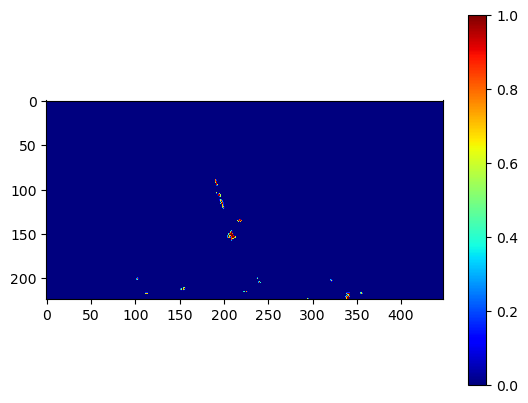

In [224]:
if out_mask_cv.max() <= 0.31 or out_mask_cv.max() >= 0.5: 
        threshold = 0.35
else:
    threshold = threshold_otsu(out_mask_cv)
binary_mask = (predicted_mask_normalized > 0.5).astype(np.uint8)
plt.imshow(binary_mask, cmap='jet')
plt.colorbar()

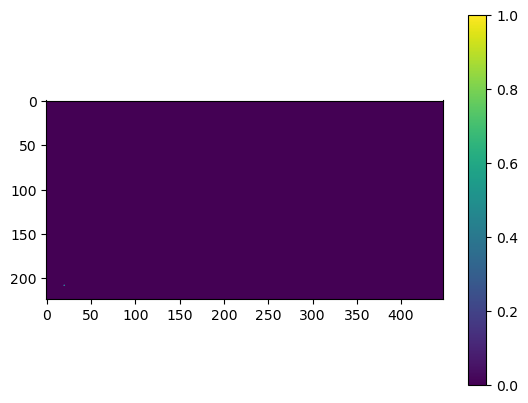

In [169]:
# Compute the Otsu threshold
otsu_threshold = threshold_otsu(out_mask_cv)

# Apply the threshold to get the binary mask
binary_pred_mask_otsu = (out_mask_cv > 0.35).astype(np.uint8)
plt.imshow(binary_pred_mask_otsu, cmap='viridis')
plt.colorbar()


In [ ]:
obj_ap_pixel_list = []
obj_auroc_pixel_list = []
obj_ap_image_list = []
obj_auroc_image_list = []


model = ReconstructiveSubNetwork(in_channels=3, out_channels=3)
model.load_state_dict(torch.load(os.path.join(checkpoint_path,run_name+".pckl"), map_location='cuda:0'))
model.cuda()
model.eval()

model_seg = DiscriminativeSubNetwork(in_channels=6, out_channels=2)
model_seg.load_state_dict(torch.load(os.path.join(checkpoint_path, run_name+"_seg.pckl"), map_location='cuda:0'))
model_seg.cuda()
model_seg.eval()

dataset = MVTecDRAEMTestDataset(mvtec_path + obj_name + "/test/", resize_shape=[img_dim, img_dim])
dataloader = DataLoader(dataset, batch_size=1,
                        shuffle=False, num_workers=0)






anomaly_score_prediction = np.array(anomaly_score_prediction)
anomaly_score_gt = np.array(anomaly_score_gt)
auroc = roc_auc_score(anomaly_score_gt, anomaly_score_prediction)
ap = average_precision_score(anomaly_score_gt, anomaly_score_prediction)

total_gt_pixel_scores = total_gt_pixel_scores.astype(np.uint8)
total_gt_pixel_scores = total_gt_pixel_scores[:img_dim * img_dim * mask_cnt]
total_pixel_scores = total_pixel_scores[:img_dim * img_dim * mask_cnt]
auroc_pixel = roc_auc_score(total_gt_pixel_scores, total_pixel_scores)
ap_pixel = average_precision_score(total_gt_pixel_scores, total_pixel_scores)
obj_auroc_pixel_list.append(auroc_pixel)
print("AUC Pixel mean:  " + str(np.mean(obj_auroc_pixel_list)))

obj_ap_pixel_list.append(ap_pixel)
obj_auroc_pixel_list.append(auroc_pixel)
obj_auroc_image_list.append(auroc)
obj_ap_image_list.append(ap)
print(obj_name)
print("AUC Image:  " +str(auroc))
print("AP Image:  " +str(ap))
print("AUC Pixel:  " +str(auroc_pixel))
print("AP Pixel:  " +str(ap_pixel))
print("==============================")

print(run_name)
print("AUC Image mean:  " + str(np.mean(obj_auroc_image_list)))
print("AP Image mean:  " + str(np.mean(obj_ap_image_list)))
print("AUC Pixel mean:  " + str(np.mean(obj_auroc_pixel_list)))
print("AP Pixel mean:  " + str(np.mean(obj_ap_pixel_list)))

write_results_to_file(run_name, obj_auroc_image_list, obj_auroc_pixel_list, obj_ap_image_list, obj_ap_pixel_list)

In [11]:
predictedp = '/home/maria/Documents/projects/anomaly_detection_vehicles/outputs/visualisations-20241212T132745Z-001/visualisations/144/200_predicted_mask.png'
maskp = '/home/maria/Documents/projects/anomaly_detection_vehicles/outputs/visualisations-20241212T132745Z-001/visualisations/144/200_original_mask.png'

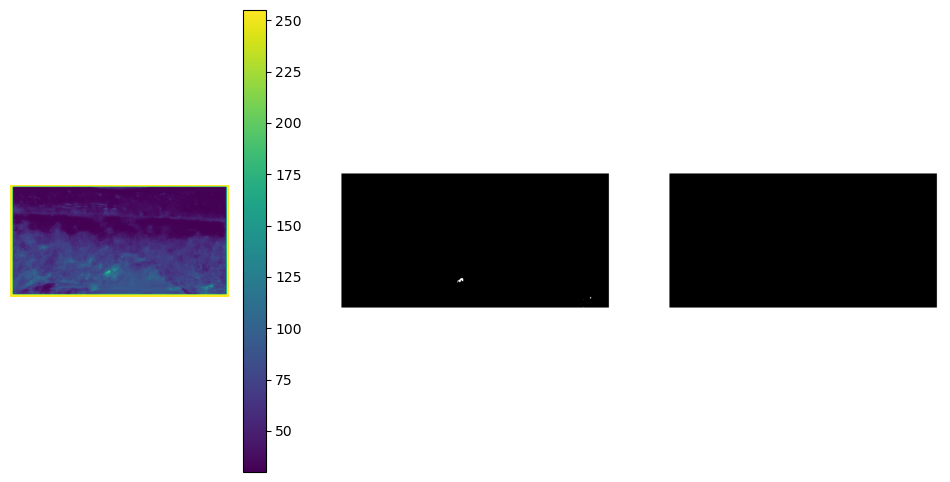

In [12]:
# Load the image in grayscale mode
image = cv2.imread(predictedp, cv2.IMREAD_GRAYSCALE)

mask = cv2.imread(maskp)

# Apply binary thresholding using Otsu's method
_, binary_image = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the original and binary images
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='viridis')
plt.colorbar()
plt.axis('off')

# Binary Image
plt.subplot(1, 3, 2)
plt.imshow(binary_image, cmap='gray')
plt.axis('off')

# Binary Image
plt.subplot(1, 3, 3)
plt.imshow(mask, cmap='gray')
plt.axis('off')


plt.show()